# 02 · What the network predicts, and the loss

We want to reverse the noising. The reverse step is also (approximately) Gaussian,
so we just need its mean. The DDPM insight: instead of predicting the mean
directly, **predict the noise** $\varepsilon$ that was added.

Given a noised $x_t$ and its timestep $t$, the network $\varepsilon_\theta(x_t, t)$
guesses the noise. Because we *know* the true $\varepsilon$ (we added it), training
is plain regression:

$$\mathcal L = \mathbb E_{x_0,\,t,\,\varepsilon}\;\big\|\varepsilon - \varepsilon_\theta(x_t, t)\big\|^2$$

Astonishingly simple — and the DDPM paper shows this MSE is a reweighting of the
true likelihood bound, so minimizing it really does train a generator.

In [1]:
import torch
import matplotlib.pyplot as plt

from nanodiffusion.utils import pick_device, set_seed
from nanodiffusion.data import toy2d
from nanodiffusion.schedules import NoiseSchedule
from nanodiffusion.forward import add_noise
from nanodiffusion.models import MLPDenoiser
from nanodiffusion.objectives import ddpm_eps_loss

set_seed(0)
device = pick_device()
print("device:", device)

device: mps


## The denoiser

For 2D data a tiny MLP suffices. It takes the noised point `x` and the timestep
`t` (embedded with sinusoids, so the network knows the noise level) and outputs a
2D noise prediction. This is `nanodiffusion.models.MLPDenoiser`.

In [2]:
model = MLPDenoiser(data_dim=2, hidden=128, depth=4, time_embed_dim=64).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n{n_params:,} parameters")

MLPDenoiser(
  (time_mlp): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): SiLU()
  )
  (net): Sequential(
    (0): Linear(in_features=66, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): SiLU()
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)

62,530 parameters


## The training loop

Each step: grab a batch, pick random timesteps, noise the batch, predict ε,
minimize MSE. `ddpm_eps_loss` wraps steps 2–5; here we keep the loop visible.

step    0   loss 1.0229


step  400   loss 0.4754


step  800   loss 0.4673


step 1200   loss 0.4794


step 1600   loss 0.4357


final loss 0.3859


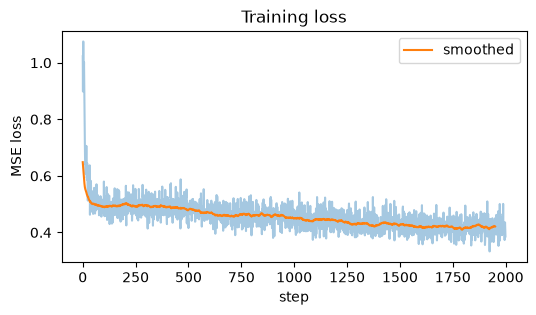

In [3]:
data = toy2d("swiss_roll", 8000).to(device)
schedule = NoiseSchedule.make("cosine", 200).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

losses = []
for step in range(2000):
    idx = torch.randint(0, data.shape[0], (512,), device=device)
    loss = ddpm_eps_loss(model, data[idx], schedule)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % 400 == 0:
        print(f"step {step:4d}   loss {loss.item():.4f}")
print(f"final loss {losses[-1]:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(losses, alpha=0.4);
plt.plot(torch.tensor(losses).unfold(0, 50, 1).mean(1), color="C1", label="smoothed")
plt.xlabel("step"); plt.ylabel("MSE loss"); plt.legend(); plt.title("Training loss"); plt.show()

## Debugging move: overfit one batch

A classic sanity check (straight from the Karpathy playbook): before trusting a
full run, confirm the model *can* drive the loss down on a single fixed batch. If
it can't overfit 128 points, something is broken.

In [4]:
probe = MLPDenoiser().to(device)
opt2 = torch.optim.Adam(probe.parameters(), lr=2e-3)
batch = data[:128]
first = None
for step in range(400):
    # fix the noise & timesteps so it's a genuine memorization test
    t = torch.randint(0, schedule.timesteps, (128,), device=device)
    x_t, noise = add_noise(batch, t, schedule)
    pred = probe(x_t, t)
    l = ((pred - noise) ** 2).mean()
    opt2.zero_grad(); l.backward(); opt2.step()
    if first is None: first = l.item()
print(f"loss: {first:.3f} -> {l.item():.3f}  (should drop a lot)")
assert l.item() < first
print("overfit check passed ✔")

loss: 1.086 -> 0.474  (should drop a lot)
overfit check passed ✔


## Save the trained model

We stash the model so notebook 03 (sampling) can load it instead of retraining.

In [5]:
import os
os.makedirs("../checkpoints", exist_ok=True)
torch.save(model.state_dict(), "../checkpoints/toy_mlp.pt")
print("saved ../checkpoints/toy_mlp.pt")

saved ../checkpoints/toy_mlp.pt


We have a trained ε-predictor. In notebook 03 we use it to walk from noise back to
a swiss roll. The loss and model now live in `nanodiffusion/objectives.py` and
`nanodiffusion/models/`.